In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
train = pd.read_csv("train_mohs.csv")
test = pd.read_csv("test_mohs.csv")
train.columns.str.strip()

Index(['id', 'allelectrons_Total', 'density_Total', 'allelectrons_Average',
       'val_e_Average', 'atomicweight_Average', 'ionenergy_Average',
       'el_neg_chi_Average', 'R_vdw_element_Average', 'R_cov_element_Average',
       'zaratio_Average', 'density_Average', 'Hardness'],
      dtype='object')

In [3]:
X = train.drop(columns=['id'],inplace=True)   # Features
test_id = test["id"]
test = test.drop(columns=["id"])---

X = train.drop(columns=["Hardness"])   # Features
y = train["Hardness"]      



SyntaxError: invalid syntax (3866357726.py, line 3)

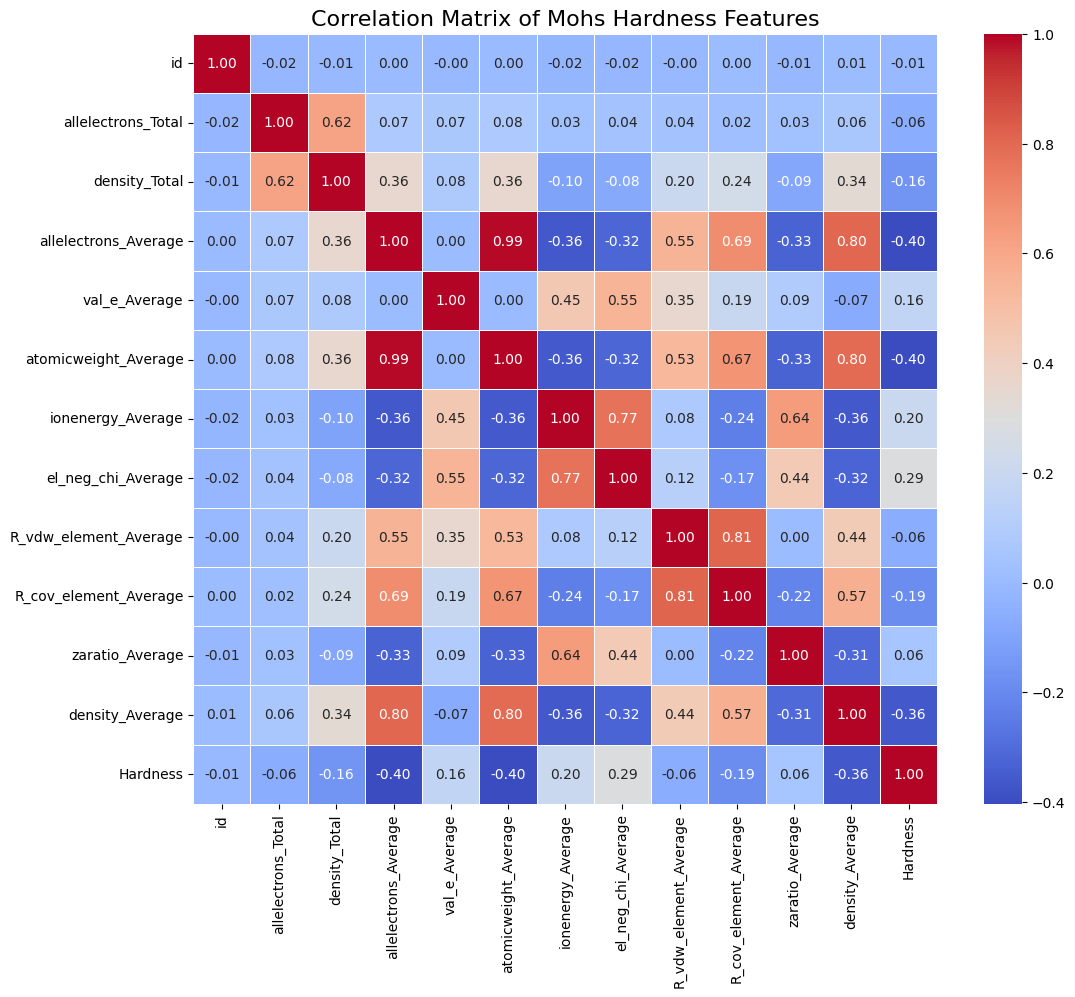

In [5]:

correlation_matrix = train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Mohs Hardness Features', fontsize=16)
plt.show()



In [6]:
model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)


NameError: name 'X' is not defined

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# List all features except the target
features = [col for col in train.columns if col != 'Hardness']

# Predict using your trained RandomForestRegressor model
y_actual = train['Hardness'].values
y_pred = model.predict(train[features])

# Set up 3D subplots
num_cols = 3
num_rows = -(-len(features) // num_cols)  # Ceiling division
fig = plt.figure(figsize=(18, 5 * num_rows))
fig.suptitle('3D Plots: Features vs Actual and Predicted Hardness', fontsize=18, y=1.02)

for i, feature in enumerate(features):
    ax = fig.add_subplot(num_rows, num_cols, i + 1, projection='3d')

    x_vals = train[feature].values

    # Plot actual values (blue)
    ax.scatter(x_vals, y_actual, y_pred, c='r', alpha=0.5, label='Data Points')

    # Plot regression "trend" line by sorting x
    sort_idx = np.argsort(x_vals)
    ax.plot(
        x_vals[sort_idx], 
        y_actual[sort_idx], 
        y_pred[sort_idx],
        color='red', linewidth=0, label='Prediction Line'
    )

    ax.set_title(f'{feature} vs Hardness', fontsize=10)
    ax.set_xlabel(feature)
    ax.set_ylabel('Actual Hardness')
    ax.set_zlabel('Predicted Hardness')
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
submission = pd.DataFrame({
    "id": test_id,
    "Hardness": preds
})

submission.to_csv("submission_mohs.csv", index=False)
print("✅ submission.csv generated successfully!")


✅ submission.csv generated successfully!


https://www.kaggle.com/competitions/playground-series-s3e25